In [2]:
import os
import sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, ROOT)
print(ROOT)

c:\Users\souza\OneDrive\Área de Trabalho\modelagem inadimplencia


In [3]:
import pandas as pd 
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils.analytics.MonteCarlo import MonteCarlo
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import r2_score

#from utils.analytics.Plot3d import Plot3d

In [4]:
# funçao de diferença logaritmica
def log_diff(X:pd.Series):
    return np.log(X).diff()

In [5]:
x_train_path = os.path.join('..','..', 'data', 'processed', 'dados_treino.csv')
X_train = pd.read_csv(x_train_path)
X_train.shape

(166, 7)

In [6]:
# vetor resposta 
y_train_path = os.path.join('..', '..','data', 'processed', 'vetor_resposta.csv')
y_train = pd.read_csv(y_train_path)
y_train = y_train.set_index('data')
y_train

,Inadimplencia_PF
data,
2012-03-01,5.36
2012-04-01,5.41
2012-05-01,5.51
2012-06-01,5.43
2012-07-01,5.42
...,...
2025-09-01,4.89
2025-10-01,4.99
2025-11-01,5.12


In [7]:
X_train = X_train.dropna()

In [8]:
X_train.isnull().sum()

intercepto                    0
Confiança_consumidor          0
Desemprego                    0
SELIC                         0
IBC-Br                        0
IPCA                          0
Endividamento_das_familias    0
dtype: int64

In [9]:
X_train = X_train.dropna()
X_train

,intercepto,Confiança_consumidor,Desemprego,SELIC,IBC-Br,IPCA,Endividamento_das_familias
0,1,0.024095,7.366499,0.741320,0.003247,0.527917,37.111279
1,1,0.040457,7.443742,0.734245,0.012553,0.454032,37.259476
2,1,-0.017547,7.412833,0.659889,0.007148,0.285128,37.425464
3,1,0.010836,7.332529,0.621403,0.001709,0.689960,37.483668
4,1,-0.029887,7.280069,0.674989,0.002983,0.656219,37.587446
...,...,...,...,...,...,...,...
161,1,-0.014982,5.755866,1.221394,-0.001507,0.478253,49.138474
162,1,0.028579,5.654327,1.224007,0.000731,0.116143,49.388298
163,1,0.026956,5.515957,1.142840,0.005121,0.219613,49.537583
164,1,0.017922,5.372552,1.209036,0.001313,0.226347,49.701265


In [10]:
# criando funçao para previsao direta do modelo
def model_MQO(X:pd.DataFrame):
    return 8 +  -0.255698 *X['Desemprego'] + 0.027675*X['SELIC'] + -0.5865815 *X['IBC-Br'] + -0.011552*X['IPCA'] + 0.753276  *X['Endividamento_das_familias']

In [11]:
# fazendo previsoes
y_pred_train = model_MQO(X_train)
X_train.shape

(166, 7)

In [12]:
resid = y_train - y_pred_train

In [13]:
print(f'média dos residuos: {resid.mean()}')
print()
print(f'desvio padrao: {resid.std()}')

média dos residuos: Inadimplencia_PF   NaN
0                  NaN
1                  NaN
2                  NaN
3                  NaN
                    ..
161                NaN
162                NaN
163                NaN
164                NaN
165                NaN
Length: 167, dtype: float64

desvio padrao: Inadimplencia_PF   NaN
0                  NaN
1                  NaN
2                  NaN
3                  NaN
                    ..
161                NaN
162                NaN
163                NaN
164                NaN
165                NaN
Length: 167, dtype: float64


# Aplicando estresses ao modelo 

In [14]:
def monte_carlo_plot(sim:pd.DataFrame, nsim:int):
    plt.figure(figsize=(12,8))
    sim_list = []
    for _ in range(nsim):
        pred = model_MQO(sim)
        y_hat = np.cumsum(pred)/np.arange(len(pred))
        y_hat = pd.Series(y_hat)
        sim_list.append(y_hat)
        plt.plot(y_hat)
    return y_hat

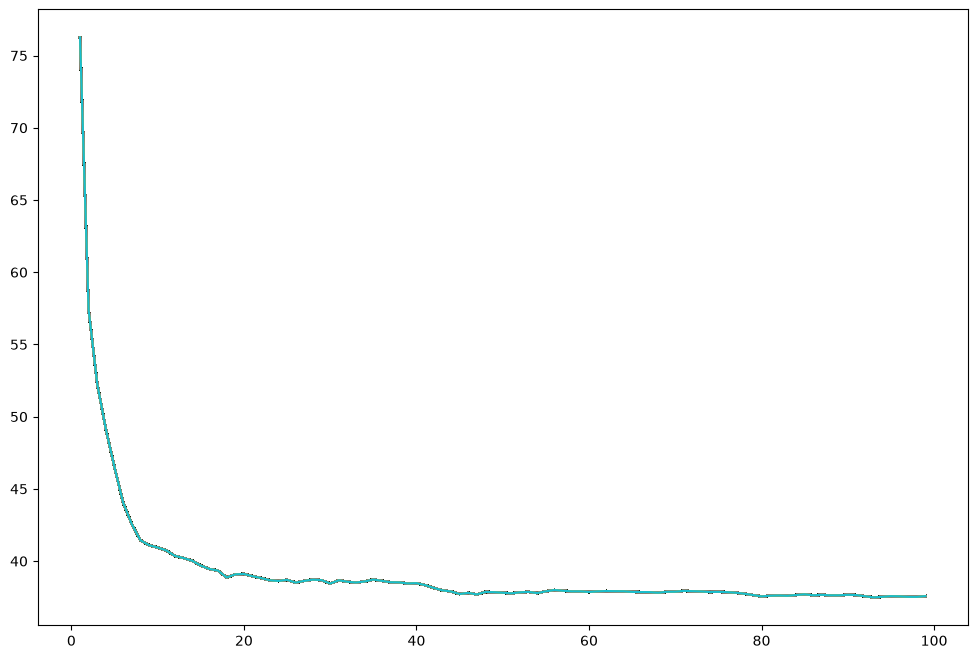

In [15]:
mc_sim = MonteCarlo(X_train)
mc_normal = mc_sim.normal_scenario(100)
y_hat = monte_carlo_plot(mc_normal, 1000)


In [16]:
# tirando o infinito 
normal_list = pd.concat([y_hat], axis=1)
normal_list = normal_list.replace(np.inf,0)


In [17]:
def RiskBands(y:pd.Series):
    y = y.replace(np.inf, 0)
    band = f"""
    Media das previsoes: {np.mean(y)}
    
    Desvio padrão: {np.std(y)}
    
    
    50%: {np.percentile(y, 50)}
    25%: {np.percentile(y, 75)}
    10%: {np.percentile(y, 90)}
    5%: {np.percentile(y, 95)}

    """

    return band

In [18]:
print(RiskBands(normal_list))


    Media das previsoes: 38.902126919904525

    Desvio padrão: 6.11067131315934


    50%: 37.90986370992552
    25%: 38.68681362679326
    10%: 40.759406667883226
    5%: 44.173068632039055

    


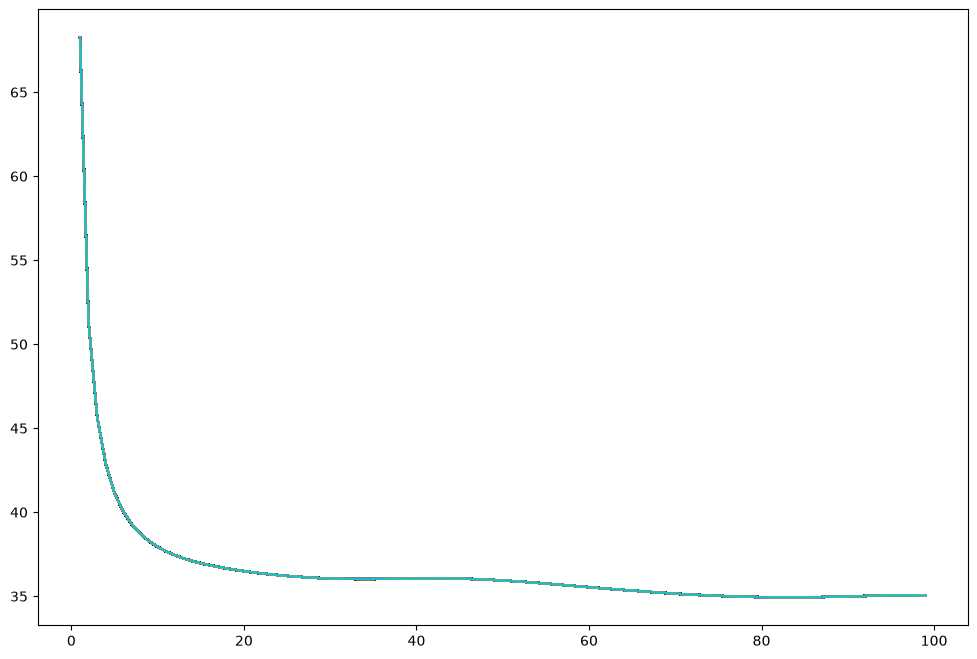

In [19]:
X_low_ibc = X_train.copy()
X_low_ibc['IBC-Br'] = mc_sim.T_student_shocks(100, 0.2, 'IBC-Br')
X_low_ibc = X_low_ibc.dropna()
y_ibc = monte_carlo_plot(X_low_ibc, 1000)


In [20]:
print(RiskBands(y_ibc))


    Media das previsoes: 36.214957919000874

    Desvio padrão: 5.31188466250841


    50%: 35.923303314549756
    25%: 36.18062594422667
    10%: 37.690401490390606
    5%: 40.104226947167355

    


Mundando o modelo - > Aplicando alguns deltas Log

In [21]:
X_new = X_train.copy()
X_new

,intercepto,Confiança_consumidor,Desemprego,SELIC,IBC-Br,IPCA,Endividamento_das_familias
0,1,0.024095,7.366499,0.741320,0.003247,0.527917,37.111279
1,1,0.040457,7.443742,0.734245,0.012553,0.454032,37.259476
2,1,-0.017547,7.412833,0.659889,0.007148,0.285128,37.425464
3,1,0.010836,7.332529,0.621403,0.001709,0.689960,37.483668
4,1,-0.029887,7.280069,0.674989,0.002983,0.656219,37.587446
...,...,...,...,...,...,...,...
161,1,-0.014982,5.755866,1.221394,-0.001507,0.478253,49.138474
162,1,0.028579,5.654327,1.224007,0.000731,0.116143,49.388298
163,1,0.026956,5.515957,1.142840,0.005121,0.219613,49.537583
164,1,0.017922,5.372552,1.209036,0.001313,0.226347,49.701265


In [22]:
# aplicando deltas em Y, desemprego e endividamento
X_new['Desemprego'] = log_diff(X_new['Desemprego'])
X_new['Endividamento_das_familias'] = log_diff(X_new['Endividamento_das_familias'])
X_new = X_new.drop('Confiança_consumidor', axis=1)


In [23]:
X_new = X_new.dropna()
X_new

,intercepto,Desemprego,SELIC,IBC-Br,IPCA,Endividamento_das_familias
1,1,0.010431,0.734245,0.012553,0.454032,0.003985
2,1,-0.004161,0.659889,0.007148,0.285128,0.004445
3,1,-0.010892,0.621403,0.001709,0.689960,0.001554
4,1,-0.007180,0.674989,0.002983,0.656219,0.002765
5,1,-0.006823,0.533984,-0.003984,0.673839,-0.003472
...,...,...,...,...,...,...
161,1,0.002395,1.221394,-0.001507,0.478253,0.003646
162,1,-0.017798,1.224007,0.000731,0.116143,0.005071
163,1,-0.024776,1.142840,0.005121,0.219613,0.003018
164,1,-0.026342,1.209036,0.001313,0.226347,0.003299


In [24]:
# aplicando y log 
y_log = log_diff(y_train)
y_log = y_log.dropna()
y_log = y_log.reset_index(drop=True)

In [25]:
# exportando para novos dados na modelagem em C 
#path_modelagem = os.path.join('..', '..', 'modeling', 'scripts', 'output', 'data_modelagem.txt')
#path_vetor_y = os.path.join('..','..', 'modeling', 'scripts', 'output', 'vetor_resposta.txt')

In [26]:
#X_new.to_csv(path_modelagem, sep=',', index=False)
#y_log.to_csv(path_vetor_y, sep=',', index=False)

In [27]:
def model_FGLS(X:pd.DataFrame):
    return -0.017306+  -0.255698 *X['Desemprego'] + 0.027675*X['SELIC'] + -0.5865815 *X['IBC-Br'] + -0.011552*X['IPCA'] + 0.753276  *X['Endividamento_das_familias']

In [28]:
y_pred_new = model_FGLS(X_new)
y_pred_new  = pd.Series(y_pred_new)
y_pred_new

1     -0.009259
2     -0.002118
3     -0.005126
4     -0.004038
5     -0.008846
         ...   
161    0.013989
162    0.023169
163    0.017390
164    0.021990
165    0.008076
Length: 165, dtype: float64

In [29]:
y_log = y_log.squeeze()

In [30]:
y_log

0      0.009285
1      0.018316
2     -0.014625
3     -0.001843
4     -0.003697
         ...   
161   -0.006116
162    0.020244
163    0.025719
164    0.000000
165    0.049534
Name: Inadimplencia_PF, Length: 166, dtype: float64

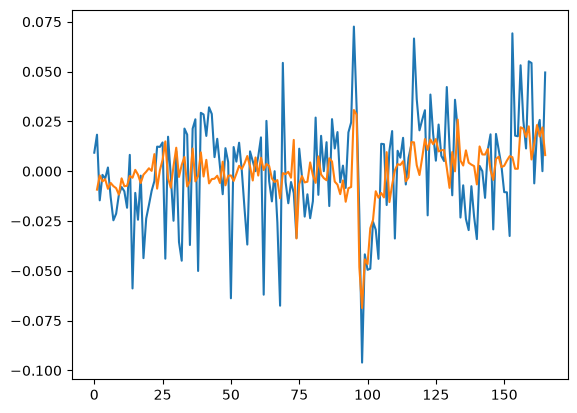

In [31]:
plt.plot(y_log)
plt.plot(y_pred_new)

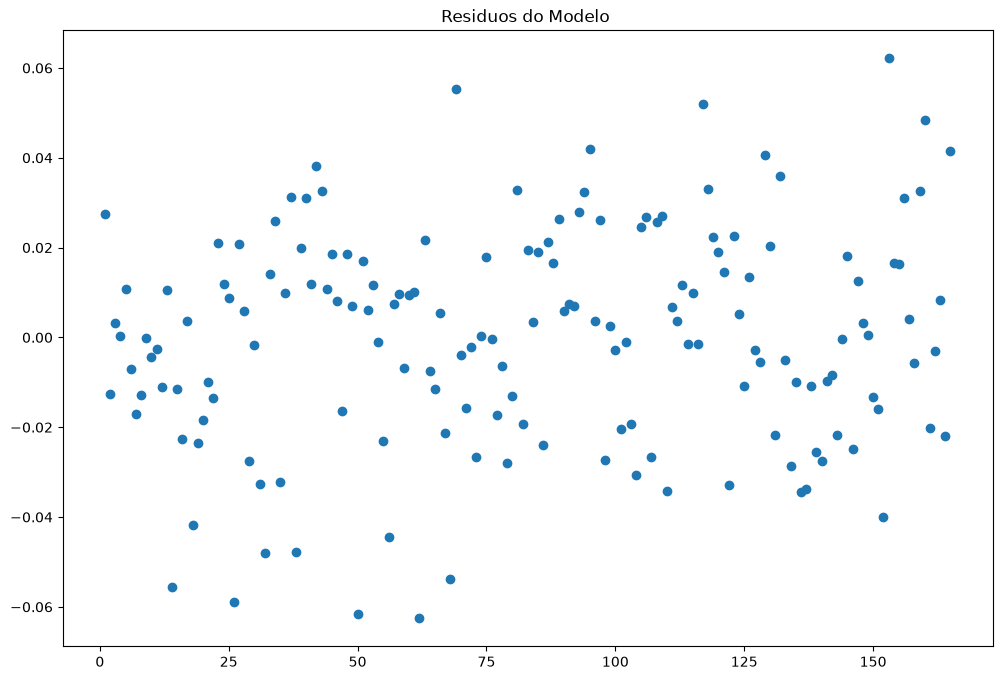

In [32]:
resid_new = y_log - y_pred_new
plt.figure(figsize=(12,8))
plt.title('Residuos do Modelo ')
plt.plot(resid_new, marker='o', linestyle='none')

In [33]:
resid_new = resid_new.dropna()

In [34]:
X_train = X_train.loc[resid_new.index]

**Teste de Breusch-Pagan**

In [35]:
het  = het_breuschpagan(resid_new, X_train)[1]
print(het)
if het < 0.05:
    print("H0: Há evidencia de heterocedasticidade")
else:
    print("Não rejeita H0: não há evidências de heterocedasticidade")


0.8276583423178544
Não rejeita H0: não há evidências de heterocedasticidade


In [36]:
def txt_print(value: float, text:str):
    txt_path = os.path.join('..', '..', 'modeling', 'scripts', 'output', 'Saida_FGLS_.txt')
    with open(txt_path, 'a') as f:
        f.write(f'{text} {value}\n')

    

In [37]:
txt_print(het, "Breusch-Pagan Test (p_value):")

**Teste de White**

In [38]:
white_test = het_white(resid_new, X_train)[1]
if white_test < 0.05:
    print("H0: os erros nao sao homocedasticos")
else:
    print("H1:os erros sao homocedasticos")

H1:os erros sao homocedasticos


In [39]:
txt_print(white_test, 'White Test (p_value):')

**p_valor para Ljing-Box**

In [41]:
ljung_box = acorr_ljungbox(resid_new,lags=12, return_df=False)
ljung_box = ljung_box['lb_pvalue']
ljung_box = np.array(ljung_box)

if ljung_box[11] <0.05:
    print('Rejeita H0: os resíduos não são independentes')
else:
    print('Nao rejeita H0: não há evidências de autocorrelação')

Rejeita H0: os resíduos não são independentes


In [42]:
txt_print(ljung_box[6], "Ljung_Box (p_value):")

In [43]:
ljung_box[6]

np.float64(3.6908292833163823e-07)

In [44]:
ljung_box

array([9.81185669e-01, 9.20127721e-01, 2.70794103e-03, 6.77114484e-03,
       1.25667322e-02, 4.63225522e-07, 3.69082928e-07, 3.36302921e-07,
       2.12583053e-07, 1.88292190e-07, 3.43389780e-07, 9.95285970e-12])

In [45]:
# calculando r quadrado simples
y_log = y_log.loc[y_pred_new.index]
rQuadrado = r2_score(y_log, y_pred_new)
txt_print(np.round(rQuadrado,3), "RQUADRADO:")